In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import random
import datetime
import torch
import torch.nn as nn
import torch.nn.functional as F
import glob
import time
import subprocess
import os
import pickle
from scipy import stats
import matplotlib.ticker as mticker
from statsmodels.nonparametric.kde import KDEUnivariate

In [2]:
# Directories repeatedly used in the notebook
split_root = '/glade/work/jstarfeldt/autoencoder/autoencoder_train_split_files'
standard_root = '/glade/work/jstarfeldt/autoencoder/standard_arrays'
dataset_root = '/glade/derecho/scratch/jstarfeldt/uhminicubes'

In [3]:
# Set random seeds for reproducability
np.random.seed(53)
torch.manual_seed(53)
random.seed(53)

## Data Visualization

In [4]:
dsL = xr.open_dataset(f'{dataset_root}/hresgrid/2022/01/KBWI/hresgrid_KBWI_202201081546.nc')
dsL

<xarray.Dataset> Size: 936MB
Dimensions:                        (y: 3000, x: 3000)
Coordinates:
  * x                              (x) float64 24kB 2.92e+05 ... 3.82e+05
  * y                              (y) float64 24kB 4.282e+06 ... 4.372e+06
    datetime                       object 8B ...
Data variables: (12/14)
    Landsat_cloud_mask             (y, x) object 72MB ...
    Landsat_blue_sfc_reflectance   (y, x) float64 72MB ...
    Landsat_green_sfc_reflectance  (y, x) float64 72MB ...
    Landsat_red_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_NIR_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_SWIR1_sfc_reflectance  (y, x) float64 72MB ...
    ...                             ...
    Sentinel1_VV                   (y, x) float64 72MB ...
    Sentinel1_VH                   (y, x) float64 72MB ...
    Sentinel1_HH                   (y, x) float64 72MB ...
    Sentinel1_HV                   (y, x) float64 72MB ...
    Sentinel1_incidence_angle      (y, x) float64 72MB ...
    spatial_ref                    int32 4B ...
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    title:          Landsat 8 and Sentinel-1 data for Washington, DC, USA and...
    institution:    University of Maryland, College Park
    source:         Satellite observation

Text(0.5, 1.0, 'Landsat LST, DMV 202201081546')

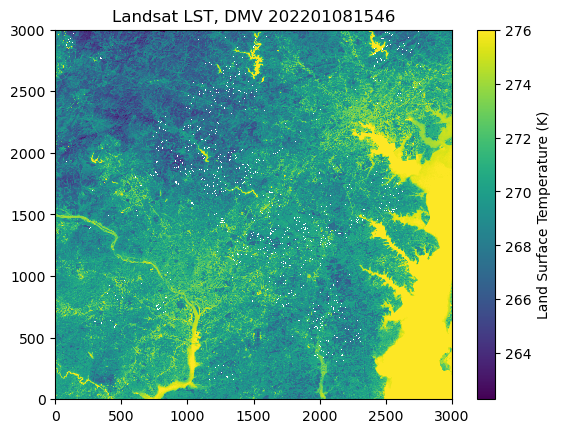

In [5]:
cb = plt.pcolormesh(dsL['Landsat_LST'], vmax=276)
plt.colorbar(cb, label='Land Surface Temperature (K)', orientation='vertical')
plt.title(f'Landsat LST, DMV 202201081546')

## Train Test Split

In [6]:
# Set list of cities in the dataset
cities = [
    'DMV', 'NYC', 'Phoenix', 'Miami', 'Chicago', 'Denver', 'Seattle', 'San_Francisco', 'Los_Angeles', 'Atlanta', 'Toronto',
    'Mexico_City', 'Las_Vegas', 'Salt_Lake_City', 'Dallas', 'Houston', 'New_Orleans', 'St_Louis', 'Minneapolis', 'Jacksonville',
    'Charlotte', 'Philadelphia', 'San_Diego', 'San_Juan', 'Montreal', 'Guadalajara', 'Monterrey', 'Cancun', 'Billings', 'Guatemala_City',
    'San_Jose', 'Havana', 'Santo_Domingo', 'Tegucigalpa', 'Managua', 'Panama_City', 'Bogota', 'Lima', 'Quito', 'Santiago', 'Buenos_Aires',
    'Sao_Paulo', 'Manaus', 'Punta_Arenas', 'La_Paz', 'Montevideo', 'Brasilia', 'Caracas'
]
cities = sorted(cities)

In [7]:
city_ICAO_codes = {
    'Atlanta': 'KATL',
    'Billings': 'KBIL',
    'Bogota': 'SKBO',
    'Brasilia': 'SBBR',
    'Buenos_Aires': 'SAEZ',
    'Cancun': 'MMUN',
    'Caracas': 'SVMI',
    'Charlotte': 'KCLT',
    'Chicago': 'KORD',
    'Dallas': 'KDFW',
    'Denver': 'KDEN',
    'Guadalajara': 'MMGL',
    'Guatemala_City': 'MGGT',
    'Havana': 'MUHA',
    'Houston': 'KIAH',
    'Jacksonville': 'KJAX',
    'La_Paz': 'SLLP',
    'Las_Vegas': 'KLAS',
    'Lima': 'SPJC',
    'Los_Angeles': 'KLAX',
    'Managua': 'MNMG',
    'Manaus': 'SBEG',
    'Mexico_City': 'MMMX',
    'Miami': 'KMIA',
    'Minneapolis': 'KMSP',
    'Monterrey': 'MMMY',
    'Montevideo': 'SUMU',
    'Montreal': 'CYUL',
    'New_Orleans': 'KMSY',
    'NYC': 'KJFK',
    'Panama_City': 'MPTO',
    'Philadelphia': 'KPHL',
    'Phoenix': 'KPHX',
    'Punta_Arenas': 'SCCI',
    'Quito': 'SEQM',
    'Salt_Lake_City': 'KSLC',
    'San_Diego': 'KSAN',
    'San_Francisco': 'KSFO',
    'San_Jose': 'MROC',
    'San_Juan': 'TJSJ',
    'Santiago': 'SCEL',
    'Santo_Domingo': 'MDSD',
    'Sao_Paulo': 'SBGR',
    'Seattle': 'KSEA',
    'St_Louis': 'KSTL',
    'Tegucigalpa': 'MHTG',
    'Toronto': 'CYYZ',
    'DMV': 'KBWI'
}

In [8]:
city_Landsat_lists = {}

for city in cities:
    city_list = []
    for year_dir in sorted(glob.glob(f'{dataset_root}/hresgrid/2*')):
        for month_dir in sorted(glob.glob(f'{year_dir}/*')):
            city_list.extend(sorted(glob.glob(f'{month_dir}/{city_ICAO_codes[city]}/*')))
    city_Landsat_lists[city] = city_list

In [9]:
def index_select(city):
    """
    Splits the Landsat files for a city into train and test files by index number.

    Args:
    city (str): The name of a city from the "cities" array

    Returns:
    train_indices (np.array): Array of indices to be train files
    test_indices (np.array): Array of indices to be test files
    """
    nFiles = len(city_Landsat_lists[city]) # number of Landsat files for the city
    nums = np.arange(nFiles)
    train_indices = np.random.choice(nums, round(nFiles*0.6), replace=False)
    test_indices = np.setdiff1d(nums, train_indices)

    return [train_indices, test_indices]

In [10]:
train_test_indices = {string: index_select(string) for string in cities}
train_test_indices

{'Atlanta': [array([54, 10,  4, 47,  3, 39, 42, 60, 40, 17, 66,  2, 55, 15, 43, 41,  1,
         34, 19,  8, 62, 13, 32, 36, 46,  7, 31, 30, 33, 44, 56,  0, 50, 21,
         28, 65, 63, 16, 59, 14,  6]),
  array([ 5,  9, 11, 12, 18, 20, 22, 23, 24, 25, 26, 27, 29, 35, 37, 38, 45,
         48, 49, 51, 52, 53, 57, 58, 61, 64, 67])],
 'Billings': [array([67, 52, 58, 56, 16, 48, 45, 44, 29, 14, 22,  0, 31, 54,  3, 62, 37,
         41,  9, 46, 70,  2,  1, 38, 18, 11,  8, 28, 19, 68, 12, 53, 30, 20,
         26, 63, 49, 42, 61, 39, 25, 40,  4]),
  array([ 5,  6,  7, 10, 13, 15, 17, 21, 23, 24, 27, 32, 33, 34, 35, 36, 43,
         47, 50, 51, 55, 57, 59, 60, 64, 65, 66, 69, 71])],
 'Bogota': [array([72, 33, 10, 56, 48, 14,  1, 15, 27, 77, 36,  9, 18, 26, 67, 29, 47,
         60, 64, 39, 21,  0, 37, 57, 50, 75,  5, 54, 16, 13, 30, 49, 42, 20,
         70, 35, 63, 22, 43,  8, 12, 73, 51, 65, 55, 38, 78]),
  array([ 2,  3,  4,  6,  7, 11, 17, 19, 23, 24, 25, 28, 31, 32, 34, 40, 41,
         44, 

In [11]:
# Calculates image dimensions to split 3000x3000
# images into 32x32 images
Landsat_dim = 3000
train_dim = 32
n_files_per_dim = int(np.floor(Landsat_dim/train_dim))
start_i = round((Landsat_dim-n_files_per_dim*train_dim)/2)
print(n_files_per_dim, start_i)

93 12


In [12]:
def split_func(city):
    """
    Splits the Landsat training images for a city from dimensions of 3000x3000 into
    smaller 32x32 images. And saves them as .npy files.

    Args:
    city (str): The name of a city from the "cities" array
    """
    train_indices = train_test_indices[city][0]
    train_file_list = np.array(city_Landsat_lists[city])[train_indices]
    existing_list = glob.glob(f'{split_root}/{city}/*')

    LST_arrays = []
    for file in train_file_list:
        arr = xr.open_dataset(file)['Landsat_LST'].values
        LST_arrays.append(arr)
    
    LST_arrays_comb = np.stack(LST_arrays)
    LST_mean = np.nanmean(LST_arrays_comb)
    LST_std = np.nanstd(LST_arrays_comb)

    standard_array = np.array([LST_mean, LST_std])
    np.save(f'{standard_root}/{city}_mean_std.npy', standard_array)

    subprocess.call(['mkdir', '-p', f'{split_root}/{city}'])

    for file in train_file_list:
        fname = file.split('/')[-1].split('.')[0]
        LST_arr = xr.load_dataset(file)['Landsat_LST'].values
    
        for i in range(n_files_per_dim):
            #print(i)
            row = i*32+start_i
            for j in range(n_files_per_dim):
                col = j*32+start_i
                #print(row, col)
                arr = LST_arr[row:row+32, col:col+32]
                if f'{split_root}/{city}/{fname}_{row}_{col}.npy' in existing_list:
                    continue
                else:
                    np.save(f'{split_root}/{city}/{fname}_{row}_{col}.npy', arr)

In [38]:
for city in cities:
    #print(city)
    split_func(city)

## Model Work

In [13]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
#from sklearn.model_selection import KFold
from torch.utils.data import Subset

In [14]:
os.system("taskset -c -p 0-95 %d" % os.getpid())

pid 30664's current affinity list: 34,35
pid 30664's new affinity list: 34,35


0

In [15]:
# Confirm how many CPUs are available for training
cpus_avail = len(os.sched_getaffinity(0))
cpus_avail

2

In [16]:
class TrainDataset(Dataset):
    """
    A dataset object to load training images for model training.
    """
    def __init__(self, img_dir, mean, std, transform=None, standardize=True):
        """
        Args:
        img_dir (str): Directory where training images are located
        mean (float): Mean value of the training images, used to standardize
                      values for training
        std (float): Standard deviation of the training images, used to
                     standardize values for training
        transform (function): Transformation function to apply to training images
        standardize (boolean): Whether to standardize dataset images
        """
        self.img_list = sorted(glob.glob(img_dir+'/*'))
        self.mean = mean
        self.std = std
        self.transform = transform
        self.standardize = standardize

        indices = np.arange(len(self.img_list))
        self.train_indices = np.random.choice(indices, round(len(indices)*0.8), replace=False)
        self.val_indices = np.setdiff1d(indices, self.train_indices)

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        """
        Args:
        idx (int): List index of the training image to get
        """
        arr = np.load(self.img_list[idx], allow_pickle=True)
        #print(self.img_list[idx])

        if self.standardize:
            arr = (arr-self.mean)/self.std

        #arr = np.concat([cloud, arr])
        image = torch.from_numpy(arr)
        if self.transform:
            image = self.transform(image)

        return torch.unsqueeze(image.to(torch.float32), 0)

In [17]:
class HeatAutoencoder(nn.Module):
    """
    Convolutional autoencoder model for Landsat LST anomaly detection.
    """
    def __init__(self):
        super(HeatAutoencoder, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.conv5 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, padding=1)
        self.conv6 = nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, padding=1)
        self.conv7 = nn.ConvTranspose2d(in_channels=16, out_channels=1, kernel_size=3, padding=1)

        self.norm1 = nn.BatchNorm2d(num_features=16)
        self.norm2 = nn.BatchNorm2d(num_features=32)
        self.norm3 = nn.BatchNorm2d(num_features=64)
        self.norm4 = nn.BatchNorm2d(num_features=64)
        self.norm5 = nn.BatchNorm2d(num_features=32)
        self.norm6 = nn.BatchNorm2d(num_features=16)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)
        self.unpool = nn.MaxUnpool2d(kernel_size=2, stride=2)
        #self.dropout = nn.Dropout2d(0.2)

    def forward(self, x):
        """
        Performs a forward pass of the autoencoder.

        Args:
        x (torch.tensor): Image tensor to run the model on
        """
        x = self.conv1(x)
        x = self.norm1(x)
        x = F.relu(x)
        x, indices1 = self.pool(x)

        x = self.conv2(x)
        x = self.norm2(x)
        x = F.relu(x)
        x, indices2 = self.pool(x)

        x = self.conv3(x)
        x = self.norm3(x)
        x = F.relu(x)
        x, indices3 = self.pool(x)

        x = self.conv4(x)
        x = self.norm4(x)
        x = F.relu(x)
        x = self.unpool(x, indices3)

        x = self.conv5(x)
        x = self.norm5(x)
        x = F.relu(x)
        x = self.unpool(x, indices2)

        x = self.conv6(x)
        x = self.norm6(x)
        x = F.relu(x)
        x = self.unpool(x, indices1)

        x = self.conv7(x)
        return x

In [18]:
loss_fn = nn.MSELoss()

def custom_loss(outputs, features, mask):
    """
    Custom loss function that calculates the mean squared error
    only where a provided binary mask equals 1.

    Args:
    outputs (torch.tensor): Output tensor from the autoencoder
    featues (torch.tensor): Input tensor to the autoencoder
    mask (torch.tensor): Pixels to mask for the loss calculation.
                         Typically denotes where pixel values are not NaN

    Returns:
    (torch.Tensor): Tensor containing the mean squared error between
                    the features and output tensors
    """
    outputs = outputs[mask == 1]
    features = features[mask == 1]

    return loss_fn(outputs, features)

In [19]:
def model_one_city(city, batch_size=128, epochs=20, lr=0.001, early_stopping_cushion=0):
    """
    Trains a convolutional autoencoder for a single city in the dataset.

    Args:
    city (str): A city from the 'cities' list
    batch_size (int): Batch size to use when training the model
    epochs (int): How many epochs to train the model for
    lr (float): Learning rate to use for the optimizer
    early_stopping_cushion (float): Cushion that a loss value is allowed to be more than
                                    a prior loss value to determine early stopping
    """
    standard_arr = np.load(f'{standard_root}/{city}_mean_std.npy')
    LST_mean = standard_arr[0]
    LST_std = standard_arr[1]

    train_dataset = TrainDataset(f'{split_root}/{city}', LST_mean, LST_std)
    model = HeatAutoencoder()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    #logging_interval = 1
    #skip_epoch_stats = False
    save_model = f'/glade/work/jstarfeldt/autoencoder/model_saves/{city}_autoencoder.pth'
    save_dict = f'/glade/work/jstarfeldt/autoencoder/dict_saves/{city}_loss_dict.pkl'

    log_dict = {'train_loss_per_batch': [],
                    'train_loss_per_epoch': [],
               'val_loss_per_fold': [],
               'val_loss_per_epoch': []}

    start_time = time.time()

    for epoch in range(epochs):
        running_train_loss = 0
        running_val_loss = 0

        # Create subsets for training and validation
        train_subset = Subset(train_dataset, train_dataset.train_indices)
        val_subset = Subset(train_dataset, train_dataset.val_indices)
        # Create dataloaders for the respective subset
        train_dataloader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=32)
        val_dataloader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=32)

        # Model training
        model.train()
        for batch_idx, features in enumerate(train_dataloader):
            mask = torch.where(torch.isnan(features), 0, 1)
            features = torch.nan_to_num(features, nan=0)
            # FORWARD AND BACK PROP
            logits = model(features)
            loss = custom_loss(logits, features, mask)
            optimizer.zero_grad()
            loss.backward()
            # UPDATE MODEL PARAMETERS
            optimizer.step()
            # LOGGING
            batch_loss = loss.item()
            running_train_loss += batch_loss

        train_loss = running_train_loss/(batch_idx+1)
        # Model validation
        with torch.no_grad():
            model.eval()
            for batch_idx, features in enumerate(val_dataloader):
                mask = torch.where(torch.isnan(features), 0, 1)
                features = torch.nan_to_num(features, nan=0)
                # FORWARD AND BACK PROP
                logits = model(features)
                loss = custom_loss(logits, features, mask)
                running_val_loss += batch_loss

        val_loss = running_val_loss/(batch_idx+1)

        print('Train Loss: %.4f | Val Loss: %.4f'  % (train_loss, val_loss))

        with torch.set_grad_enabled(False):  # save memory during inference
            print('***Epoch: %03d/%03d | Loss: %.3f' % (
                  epoch+1, epochs, running_train_loss))

        torch.save(model.state_dict(), save_model) # Save model
        log_dict['train_loss_per_epoch'].append(train_loss) # Append losses
        log_dict['val_loss_per_epoch'].append(val_loss)
        with open(save_dict, 'wb') as file: # Save loss dictionary
            pickle.dump(log_dict, file)

        if epoch >= 2:
            if (log_dict['val_loss_per_epoch'][-2] > log_dict['val_loss_per_epoch'][-3] and
                log_dict['val_loss_per_epoch'][-1] > log_dict['val_loss_per_epoch'][-2] + early_stopping_cushion):
                print('Early stopping')
                break

        print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))
    print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))

In [17]:
for city in cities:
    print(city)
    model_one_city(city)

Bogota
Train Loss: 0.0427 | Val Loss: 0.0390
***Epoch: 001/020 | Loss: 108.416
Time elapsed: 4.96 min
Train Loss: 0.0094 | Val Loss: 0.0065
***Epoch: 002/020 | Loss: 23.888
Time elapsed: 9.93 min
Train Loss: 0.0066 | Val Loss: 0.0027
***Epoch: 003/020 | Loss: 16.820
Time elapsed: 14.91 min
Train Loss: 0.0057 | Val Loss: 0.0050
***Epoch: 004/020 | Loss: 14.513
Time elapsed: 19.89 min
Train Loss: 0.0049 | Val Loss: 0.0080
***Epoch: 005/020 | Loss: 12.509
Early stopping
Total Training Time: 24.84 min


## Load model and testing

In [20]:
# Dictionary where Landsat/Sentinel-1 file datetimes and
# date strings are logged for each city in the dataset
date_dict = {string: [] for string in cities}
date_str_dict = {string: [] for string in cities}

In [21]:
# For each city in the dataset, get the datetimes and
# date strings of Landsat/Sentinel-1 files
format_string = "%Y%m%d%H%M"

for city in cities:
    #print(city)
    city_list = city_Landsat_lists[city]
    for file in city_list:
        #print(file)
        dt_str = file.split('_')[-1].split('.')[0]
        dt = datetime.datetime.strptime(dt_str, format_string)
        date_dict[city].append(dt)
        date_str_dict[city].append(dt_str[:8])

In [22]:
# Chose a city to load the model for
city = 'Las_Vegas'
save_model = f'/glade/work/jstarfeldt/autoencoder/model_saves/{city}_autoencoder.pth'
save_dict = f'/glade/work/jstarfeldt/autoencoder/dict_saves/{city}_loss_dict.pkl'
model = HeatAutoencoder()
model.load_state_dict(torch.load(save_model, weights_only=True))

<All keys matched successfully>

In [23]:
with open(save_dict, 'rb') as file:
    log_dict = pickle.load(file)

In [24]:
train_losses = np.array(log_dict['train_loss_per_epoch'])
train_losses

array([0.03606862, 0.00647774, 0.00491809, 0.00433176, 0.00408398,
       0.0038809 , 0.00355752, 0.00361833, 0.00326634, 0.00334126,
       0.00312564])

In [25]:
val_losses = np.array(log_dict['val_loss_per_epoch'])
val_losses

array([0.00593151, 0.00438693, 0.00180084, 0.00205615, 0.00107054,
       0.00509903, 0.0012904 , 0.00319906, 0.00158005, 0.0036865 ,
       0.00447617])

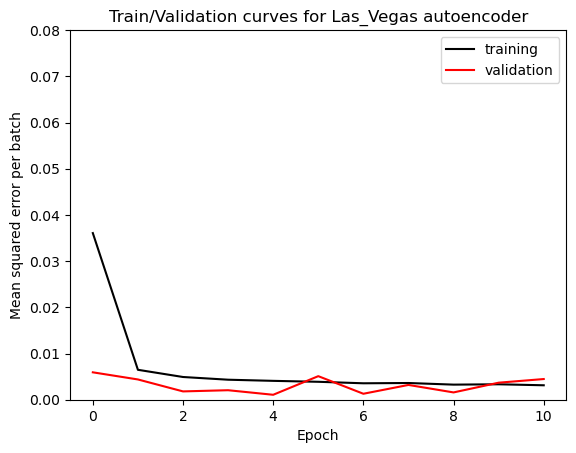

In [26]:
plt.plot(train_losses, c='k', label='training')
plt.plot(val_losses, c='r', label='validation')
plt.xlabel('Epoch')
plt.ylabel('Mean squared error per batch')
plt.ylim(0, 0.08)
plt.title(f'Train/Validation curves for {city} autoencoder')
plt.legend()
plt.show()

In [27]:
class AnalysisDataset(Dataset):
    """
    A dataset object to load test images for analysis.
    """
    def __init__(self, city, transform=None, standardize=True):
        """
        Args:
        city (str): City from 'cities' list
        transform (function): Transformation function to apply to training images
        standardize (boolean): Whether to standardize dataset images
        """
        test_indices = train_test_indices[city][1]
        standard_arr = np.load(f'{standard_root}/{city}_mean_std.npy')
        self.img_list = np.array(city_Landsat_lists[city])[test_indices]
        self.var_mean = standard_arr[0]
        self.var_std = standard_arr[1]
        self.transform = transform
        self.standardize = standardize

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        ds = xr.open_dataset(self.img_list[idx])
        arr = ds['Landsat_LST'].values

        if self.standardize:
            arr = (arr-self.var_mean)/self.var_std

        image = torch.from_numpy(arr.astype(np.float32))
        if self.transform:
            image = self.transform(image)

        return image

In [28]:
analysis_dataset = AnalysisDataset(city)

In [29]:
def get_reconstructed_data(image, model, LST_mean, LST_std):
    """
    Takes a feature image and calculates its reconstruction.

    Args:
    image (torch.tensor): Input feature image
    model (HeatAutoencoder): Trained autoencoder model
    LST_mean (float): Mean value of train dataset LST images
    LST_std (float): Standard deviation value of train dataset LST images

    Returns:
    a (torch.tensor): Input feature image in Kelvin
    b (torch.tensor): Output reconstructed image in Kelvin
    """
    image = torch.expand_copy(image, size=(1, 1, 3000, 3000))

    features = torch.nan_to_num(image, nan=0)
    # Forward prop
    logits = model(features)

    a = features*LST_std + LST_mean # Reconstructed features
    b = logits*LST_std + LST_mean # Reconstructed outputs

    return a, b.detach()

In [30]:
a, b = get_reconstructed_data(analysis_dataset[4], model, analysis_dataset.var_mean, analysis_dataset.var_std)

Text(0.5, 1.0, 'Original')

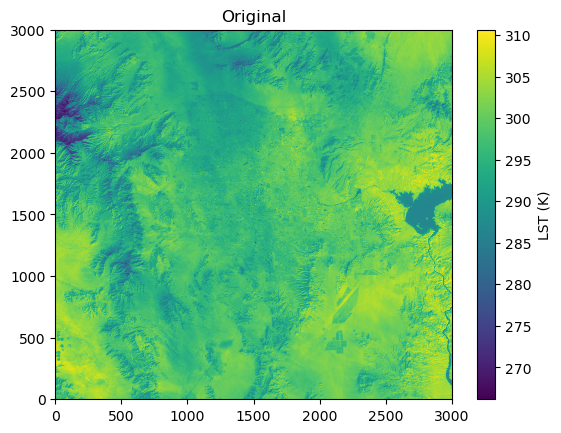

In [31]:
cb = plt.pcolormesh(a[0,0])
plt.colorbar(cb, label='LST (K)', orientation='vertical')
plt.title('Original')

Text(0.5, 1.0, 'Reconstructed')

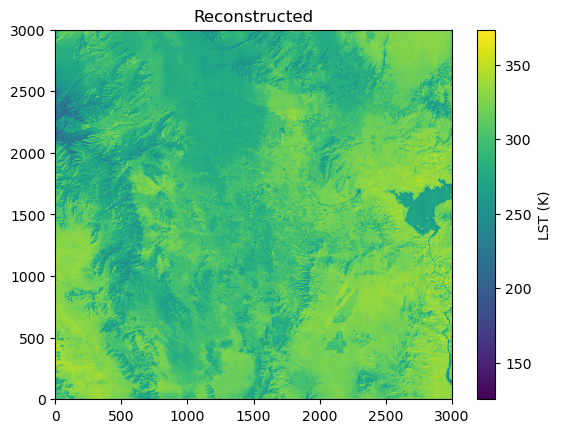

In [32]:
cb = plt.pcolormesh(b[0,0])#, vmin=torch.min(a[0,0]), vmax=torch.max(a[0,0]))
plt.colorbar(cb, label='LST (K)', orientation='vertical')
plt.title('Reconstructed')

Text(0.5, 1.0, 'Absolute LST Reconstruction Error')

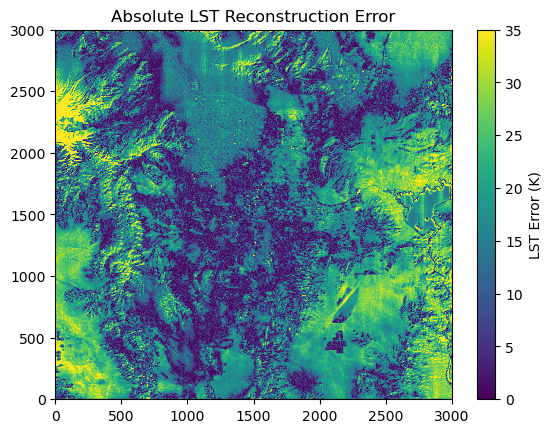

In [33]:
cb = plt.pcolormesh(torch.abs(a-b)[0,0], vmax=35)
plt.colorbar(cb, label='LST Error (K)', orientation='vertical')
plt.title('Absolute LST Reconstruction Error')

## Autoencoder Surface Type Analysis

In [34]:
# Dictionary for full city name strings
city_str_dict = {
    'Atlanta': 'Atlanta, Georgia, USA',
    'Billings': 'Billings, Montana, USA',
    'Bogota': 'Bogota, Colombia',
    'Brasilia': 'Brasilia, Brazil',
    'Buenos_Aires': 'Buenos Aires, Argentina',
    'Cancun': 'Cancun, Mexico',
    'Caracas': 'Caracas, Venezuela',
    'Charlotte': 'Charlotte, North \nCarolina, USA',
    'Chicago': 'Chicago, Illinois, USA',
    'Dallas': 'Dallas, Texas, USA and \nFort Worth, Texas, USA',
    'Denver': 'Denver, Colorado, USA',
    'Guadalajara': 'Guadalajara, Mexico',
    'Guatemala_City': 'Guatemala City, Guatemala',
    'Havana': 'Havana, Cuba',
    'Houston': 'Houston, Texas, USA',
    'Jacksonville': 'Jacksonville, Florida, USA',
    'La_Paz': 'La Paz, Bolivia',
    'Las_Vegas': 'Las Vegas, Nevada, USA',
    'Lima': 'Lima, Peru',
    'Los_Angeles': 'Los Angeles, California, USA',
    'Managua': 'Managua, Nicaragua',
    'Manaus': 'Manaus, Brazil',
    'Mexico_City': 'Mexico City, Mexico',
    'Miami': 'Miami, Florida, USA',
    'Minneapolis': 'Minneapolis, \nMinnesota, USA',
    'Monterrey': 'Monterrey, Mexico',
    'Montevideo': 'Montevideo, Uruguay',
    'Montreal': 'Montreal, Quebec, Canada',
    'New_Orleans': 'New Orleans, \nLouisiana, USA',
    'NYC': 'New York City, \nNew York, USA',
    'Panama_City': 'Panama City, Panama',
    'Philadelphia': 'Philadelphia, \nPennsylvania, USA',
    'Phoenix': 'Phoenix, Arizona, USA',
    'Punta_Arenas': 'Punta Arenas, Chile',
    'Quito': 'Quito, Ecuador',
    'Salt_Lake_City': 'Salt Lake City, Utah, USA',
    'San_Diego': 'San Diego, California, \nUSA and Tijuana, Mexico',
    'San_Francisco': 'San Francisco, California, USA \nand San Jose, California, USA',
    'San_Jose': 'San Jose, Costa Rica',
    'San_Juan': 'San Juan, Puerto Rico',
    'Santiago': 'Santiago, Chile',
    'Santo_Domingo': 'Santo Domingo, \nDominican Republic',
    'Sao_Paulo': 'Sao Paulo, Brazil',
    'Seattle': 'Seattle, Washington, USA',
    'St_Louis': 'St Louis, Missouri, USA',
    'Tegucigalpa': 'Tegucigalpa, Honduras',
    'Toronto': 'Toronto, Ontario, Canada',
    'DMV': 'Washington, DC, USA and \nBaltimore, Maryland, USA'
}

In [35]:
def cloud(val):
    """
    Gets the 'cloud' bit from a Landsat cloud mask bit string.

    Args:
    val (str): Bit string from the Landsat Cloud Mask

    Returns:
    (boolean): True if the pixel value contains a cloud. Otherwise, False.
    """
    try:
        return (str(int(val))[-4] == '1')
    except:
        return False


def shadow(val):
    """
    Gets the 'cloud shadow' bit from a Landsat cloud mask bit string.

    Args:
    val (str): Bit string from the Landsat Cloud Mask

    Returns:
    (boolean): True if the pixel value contains a
               cloud shadow. Otherwise, False.
    """
    try:
        return (str(int(val))[-5] == '1')
    except:
        return False


def water(val):
    """
    Gets the 'water' bit from a Landsat cloud mask bit string.

    Args:
    val (str): Bit string from the Landsat Cloud Mask

    Returns:
    (boolean): True if the pixel value contains water. Otherwise, False.
    """
    try:
        return (str(int(val))[-8] == '1')
    except:
        return False


# Vectorize the functions to work on arrays
cloud_func = np.vectorize(cloud)
shadow_func = np.vectorize(shadow)
water_func = np.vectorize(water)

In [36]:
# Test out the vectorized functions
ds = xr.open_dataset(analysis_dataset.img_list[0])
mask = ds['Landsat_cloud_mask'].values
cloud_arr = cloud_func(mask)
shadow_arr = shadow_func(mask)
water_arr = water_func(mask)

In [37]:
def get_reconstruction_error_by_feature(city):
    """
    Calculates the average reconstruction errors across cloud, cloud shadow,
    water, and other pixels for each image in a city's test dataset.

    Args:
    city (str): City from the 'cities' list

    Returns:
    other_losses (np.array): Array of average losses across the 'other' pixel type
    cloud_losses (np.array): Array of average losses across the 'cloud' pixel type
    shadow_losses (np.array): Array of average losses across the 'shadow' pixel type
    water_losses (np.array): Array of average losses across the 'water' pixel type
    """
    # Make arrays to store loss values
    analysis_dataset = AnalysisDataset(f'{dataset_root}/{city}/processed_Landsat', city)
    cloud_losses = np.zeros(len(analysis_dataset))
    shadow_losses = np.zeros(len(analysis_dataset))
    water_losses = np.zeros(len(analysis_dataset))
    other_losses = np.zeros(len(analysis_dataset))

    # Load model for the city
    save_model = f'/glade/work/jstarfeldt/autoencoder/model_saves/{city}_autoencoder.pth'
    model = HeatAutoencoder()
    model.load_state_dict(torch.load(save_model, weights_only=True))

    # For each image in the city's test dataset, calculate the average
    # reconstruction error by pixel type
    i = 0
    for i in range(len(analysis_dataset)):
        # Retrieve the Landsat cloud mask for the image
        ds = xr.open_dataset(analysis_dataset.img_list[i])
        mask = ds['Landsat_cloud_mask'].values

        # Get arrays denoting each pixel type
        cloud_arr = cloud_func(mask)
        shadow_arr = shadow_func(mask)
        water_arr = water_func(mask)
        other_arr = np.logical_and(np.logical_and(cloud_arr == 0, shadow_arr == 0), water_arr == 0)

        # Calculate the absolute reconstruction error
        orig, reconstructed = get_reconstructed_data(analysis_dataset[i], model, analysis_dataset.var_mean, analysis_dataset.var_std)
        errors = torch.abs(orig-reconstructed)[0, 0]

        # Calculate the average reconstruction errors for each pixel type.
        # Each numerator is the sum of the errors where the pixel type array
        # equals 1. Each denominator is the number of pixels of the given type.
        other_losses[i] = np.sum(np.where(other_arr, errors, 0))/np.sum(other_arr)
        cloud_losses[i] = np.sum(np.where(cloud_arr, errors, 0))/np.sum(cloud_arr)
        shadow_losses[i] = np.sum(np.where(shadow_arr, errors, 0))/np.sum(shadow_arr)
        water_losses[i] = np.sum(np.where(water_arr, errors, 0))/np.sum(water_arr)

    return other_losses, cloud_losses, shadow_losses, water_losses

In [24]:
# For each city in the dataset, calculate the average
# reconstruction errors of each pixel type
overall_losses_all_city = []
cloud_losses_all_city = []
shadow_losses_all_city = []
water_losses_all_city = []

for city in cities:
    print(city)
    overall_losses, cloud_losses, shadow_losses, water_losses = get_reconstruction_error_by_feature(city)
    overall_losses_all_city.append(overall_losses)
    cloud_losses_all_city.append(cloud_losses)
    shadow_losses_all_city.append(shadow_losses)
    water_losses_all_city.append(water_losses)

# Save the lists of city reconstruction errors as pickles
with open('/glade/work/jstarfeldt/autoencoder/other_reconstruction_losses_all.pkl', 'wb') as file:
    pickle.dump(overall_losses_all_city, file)
with open('/glade/work/jstarfeldt/autoencoder/cloud_reconstruction_losses_all.pkl', 'wb') as file:
    pickle.dump(cloud_losses_all_city, file)
with open('/glade/work/jstarfeldt/autoencoder/shadow_reconstruction_losses_all.pkl', 'wb') as file:
    pickle.dump(shadow_losses_all_city, file)
with open('/glade/work/jstarfeldt/autoencoder/water_reconstruction_losses_all.pkl', 'wb') as file:
    pickle.dump(water_losses_all_city, file)

Atlanta


/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:26: RuntimeWarning: invalid value encountered in divide
  other_losses[i] = np.sum(np.where(other_arr, errors, 0))/np.sum(other_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:29: RuntimeWarning: invalid value encountered in divide
  water_losses[i] = np.sum(np.where(water_arr, errors, 0))/np.sum(water_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:26: RuntimeWarning: invalid value encountered in divide
  other_losses[i] = np.sum(np.where(other_arr, errors, 0))/np.sum(other_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:29: RuntimeWarning: invalid value encountered in divide
  water_losses[i] = np.sum(np.where(water_arr, errors, 0))/np.sum(water_arr)


Billings


/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:29: RuntimeWarning: invalid value encountered in divide
  water_losses[i] = np.sum(np.where(water_arr, errors, 0))/np.sum(water_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:28: RuntimeWarning: invalid value encountered in divide
  shadow_losses[i] = np.sum(np.where(shadow_arr, errors, 0))/np.sum(shadow_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:26: RuntimeWarning: invalid value encountered in divide
  other_losses[i] = np.sum(np.where(other_arr, errors, 0))/np.sum(other_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:29: RuntimeWarning: invalid value encountered in divide
  water_losses[i] = np.sum(np.where(water_arr, errors, 0))/np.sum(water_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:26: RuntimeWarning: invalid value encountered in divide
  other_losses[i] = np.sum(np.where(other_arr, errors, 0))/np.sum(other_ar

Bogota


...

/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:26: RuntimeWarning: invalid value encountered in divide
  other_losses[i] = np.sum(np.where(other_arr, errors, 0))/np.sum(other_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:29: RuntimeWarning: invalid value encountered in divide
  water_losses[i] = np.sum(np.where(water_arr, errors, 0))/np.sum(water_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:26: RuntimeWarning: invalid value encountered in divide
  other_losses[i] = np.sum(np.where(other_arr, errors, 0))/np.sum(other_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:29: RuntimeWarning: invalid value encountered in divide
  water_losses[i] = np.sum(np.where(water_arr, errors, 0))/np.sum(water_arr)


St_Louis


/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:26: RuntimeWarning: invalid value encountered in divide
  other_losses[i] = np.sum(np.where(other_arr, errors, 0))/np.sum(other_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:29: RuntimeWarning: invalid value encountered in divide
  water_losses[i] = np.sum(np.where(water_arr, errors, 0))/np.sum(water_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:26: RuntimeWarning: invalid value encountered in divide
  other_losses[i] = np.sum(np.where(other_arr, errors, 0))/np.sum(other_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:29: RuntimeWarning: invalid value encountered in divide
  water_losses[i] = np.sum(np.where(water_arr, errors, 0))/np.sum(water_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:26: RuntimeWarning: invalid value encountered in divide
  other_losses[i] = np.sum(np.where(other_arr, errors, 0))/np.sum(other_arr)


Tegucigalpa
Toronto


/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:26: RuntimeWarning: invalid value encountered in divide
  other_losses[i] = np.sum(np.where(other_arr, errors, 0))/np.sum(other_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:29: RuntimeWarning: invalid value encountered in divide
  water_losses[i] = np.sum(np.where(water_arr, errors, 0))/np.sum(water_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:26: RuntimeWarning: invalid value encountered in divide
  other_losses[i] = np.sum(np.where(other_arr, errors, 0))/np.sum(other_arr)
/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_37542/449480165.py:29: RuntimeWarning: invalid value encountered in divide
  water_losses[i] = np.sum(np.where(water_arr, errors, 0))/np.sum(water_arr)


In [38]:
# Open the lists of city reconstruction errors
with open('/glade/work/jstarfeldt/autoencoder/other_reconstruction_losses_all.pkl', 'rb') as file:
    overall_losses_all_city = pickle.load(file)
with open('/glade/work/jstarfeldt/autoencoder/cloud_reconstruction_losses_all.pkl', 'rb') as file:
    cloud_losses_all_city = pickle.load(file)
with open('/glade/work/jstarfeldt/autoencoder/shadow_reconstruction_losses_all.pkl', 'rb') as file:
    shadow_losses_all_city = pickle.load(file)
with open('/glade/work/jstarfeldt/autoencoder/water_reconstruction_losses_all.pkl', 'rb') as file:
    water_losses_all_city = pickle.load(file)

In [39]:
# Fit a PDF to the reconstruction errors of each pixel type,
# over every city in the dataset
overall_arr = np.concatenate(overall_losses_all_city)
cloud_arr = np.concatenate(cloud_losses_all_city)
shadow_arr = np.concatenate(shadow_losses_all_city)
water_arr = np.concatenate(water_losses_all_city)

overall_max = np.nanmax(overall_arr)
cloud_max = np.nanmax(cloud_arr)
shadow_max = np.nanmax(shadow_arr)
water_max = np.nanmax(water_arr)
max_max = np.nanmax([overall_max, cloud_max, shadow_max, water_max])

x = np.arange(0, max_max)

nan_mask = np.isnan(overall_arr)
overall_pdf = KDEUnivariate(overall_arr[~nan_mask])
overall_pdf.fit()

nan_mask = np.isnan(cloud_arr)
cloud_pdf = KDEUnivariate(cloud_arr[~nan_mask])
cloud_pdf.fit()

nan_mask = np.isnan(shadow_arr)
shadow_pdf = KDEUnivariate(shadow_arr[~nan_mask])
shadow_pdf.fit()

nan_mask = np.isnan(water_arr)
water_pdf = KDEUnivariate(water_arr[~nan_mask])
water_pdf.fit()

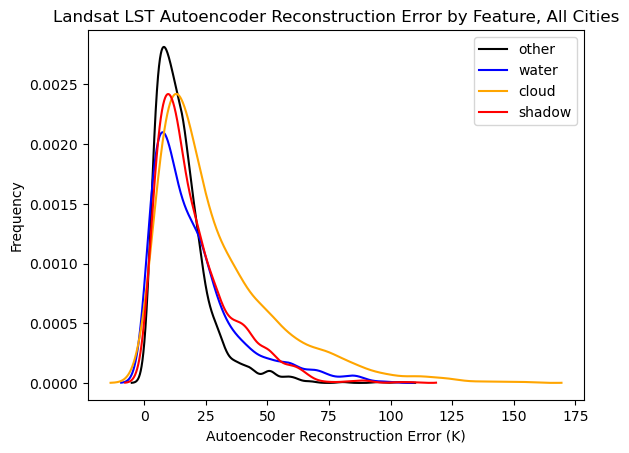

In [40]:
# Plot the PDFs of pixel reconstruction errors over the entire dataset
plt.plot(overall_pdf.support, overall_pdf.density/np.sum(overall_pdf.density),
         label='other', linewidth=1.5, color='k')
plt.plot(water_pdf.support, water_pdf.density/np.sum(water_pdf.density),
         label='water', linewidth=1.5, color='blue')
plt.plot(cloud_pdf.support, cloud_pdf.density/np.sum(cloud_pdf.density),
         label='cloud', linewidth=1.5, color='orange')
plt.plot(shadow_pdf.support, shadow_pdf.density/np.sum(shadow_pdf.density),
         label='shadow', linewidth=1.5, color='red')
plt.title('Landsat LST Autoencoder Reconstruction Error by Feature, All Cities')
plt.xlabel('Autoencoder Reconstruction Error (K)')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('/glade/work/jstarfeldt/autoencoder/average_feature_reconstruction_error.svg', transparent=True, bbox_inches='tight')

0
1
2
3
4
5
6
7


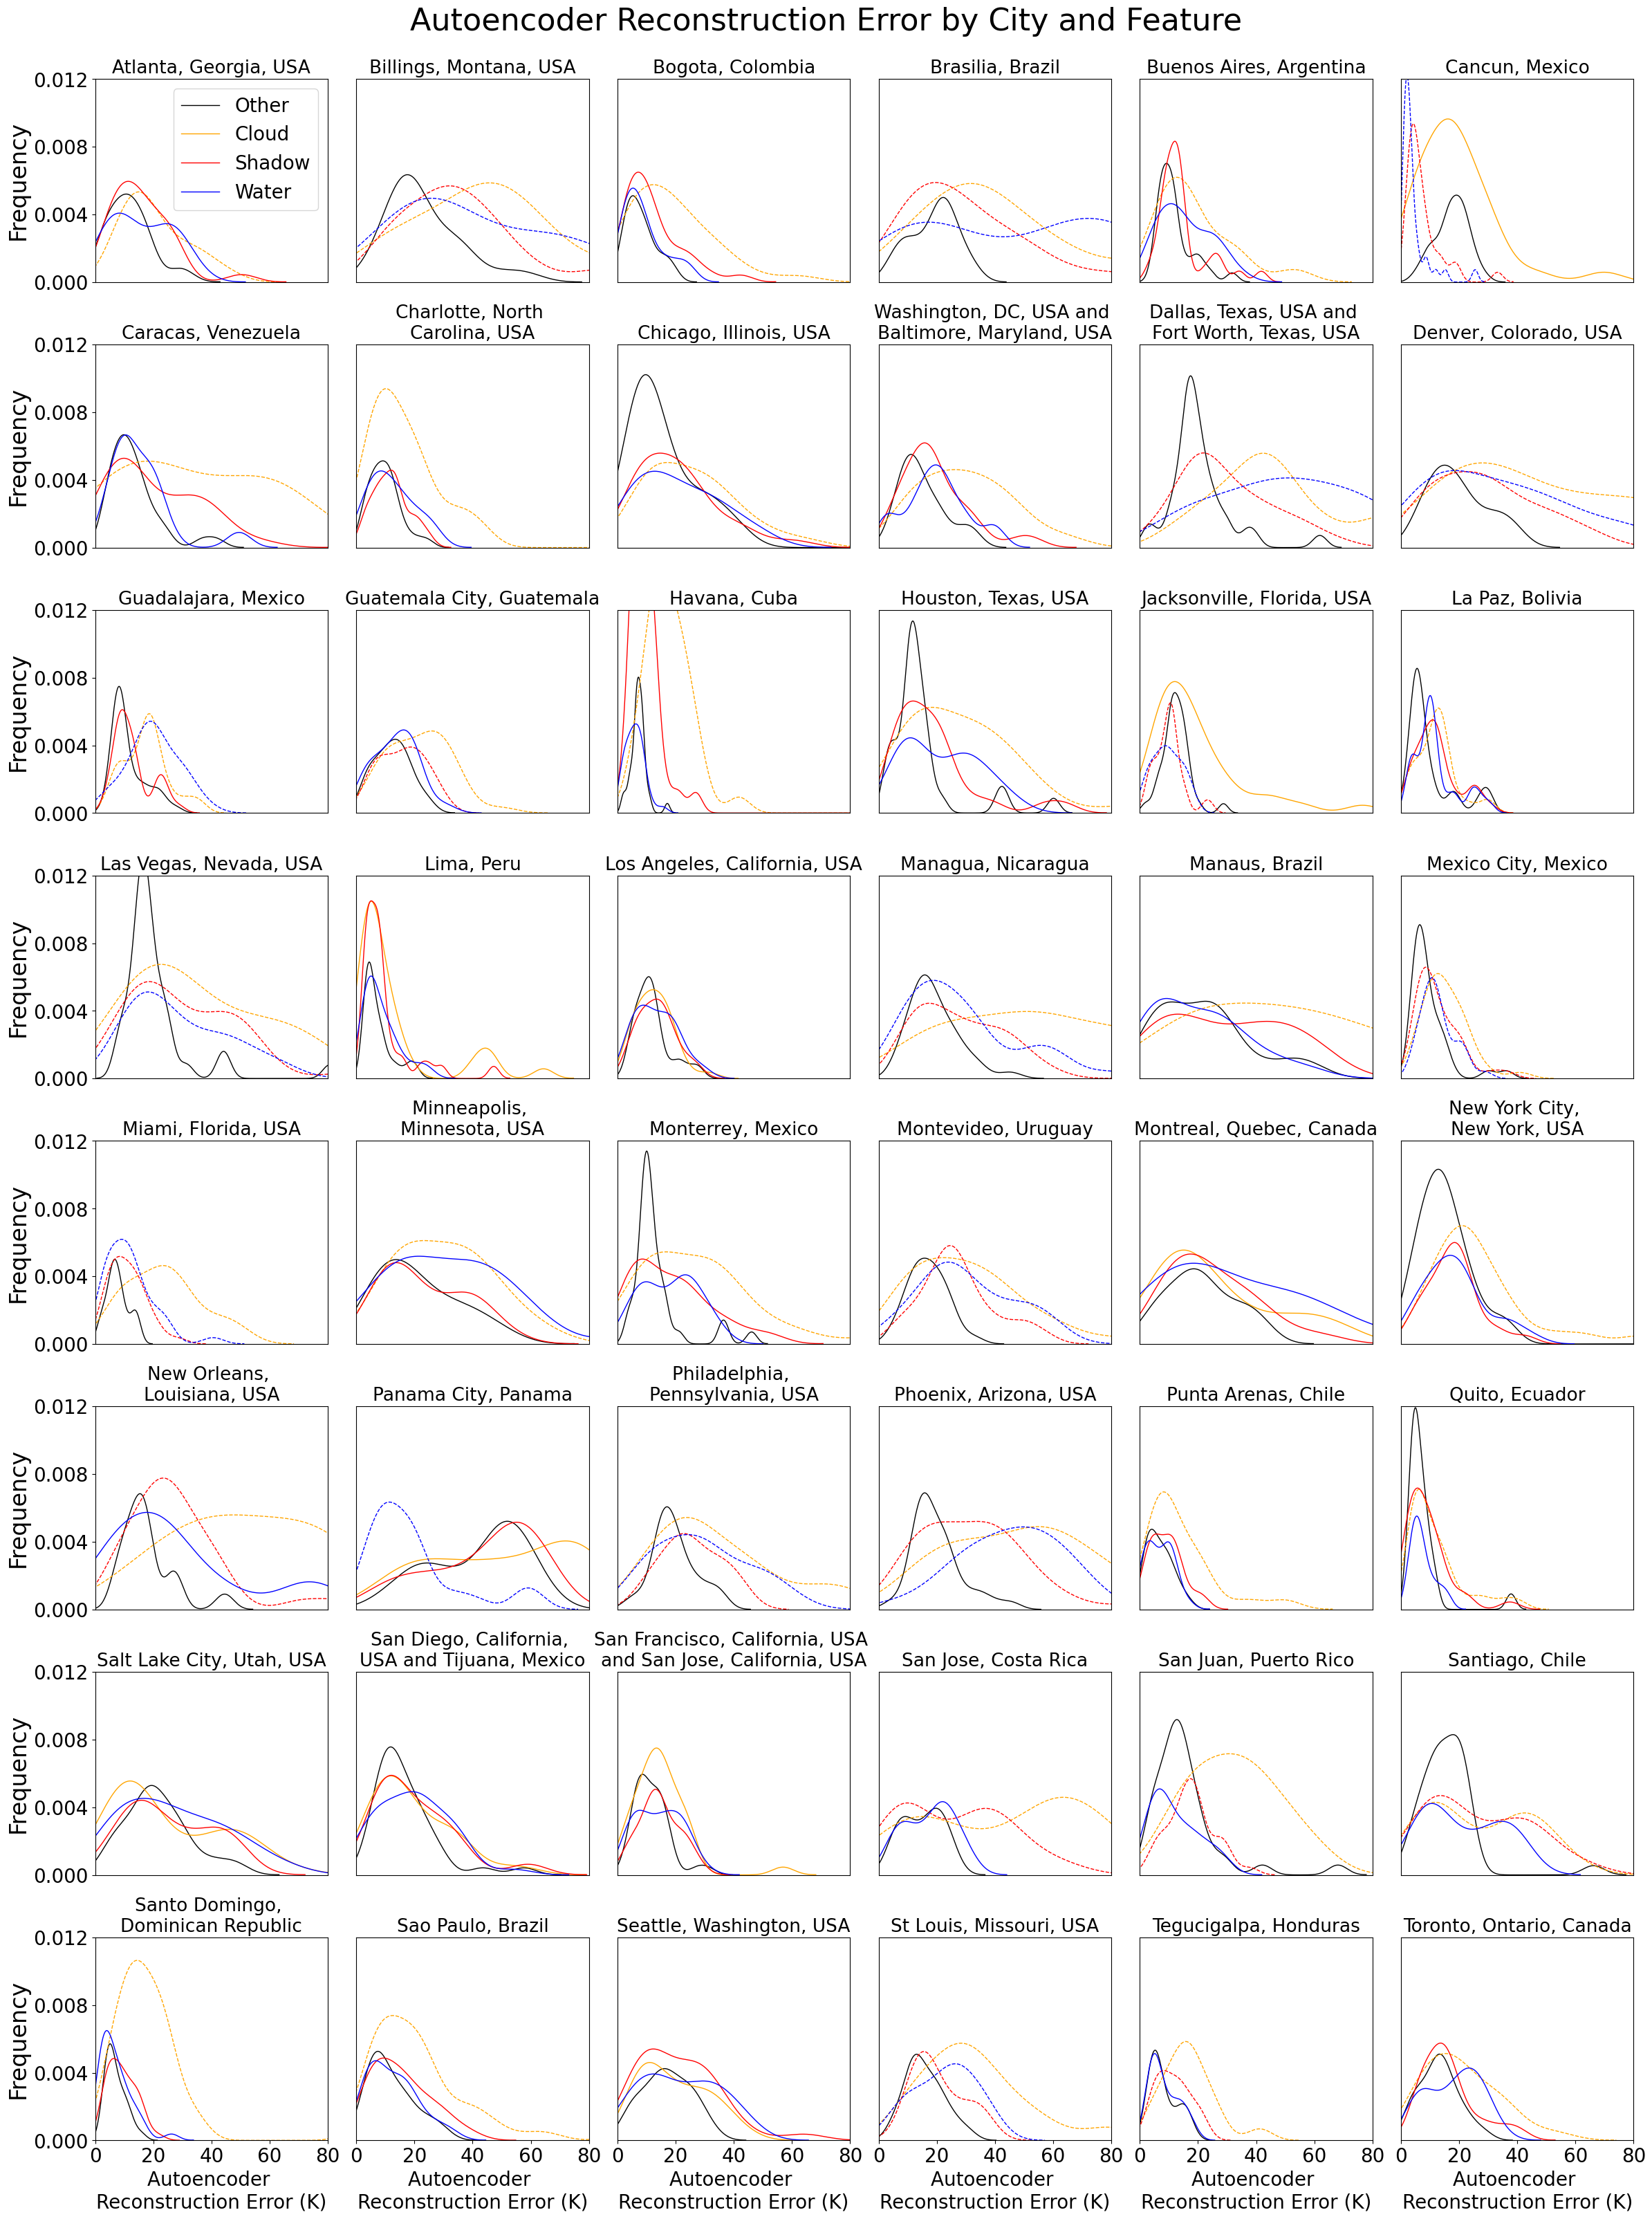

In [41]:
# Set up plot axes and general variables
fig, axs = plt.subplots(8, 6)
fig.set_size_inches(24, 32)
formatter_y = mticker.StrMethodFormatter("{x:.3f}")
x = np.arange(0, 60)

for i in range(8):
    print(i)
    for j in range(6):
        # Grab the reconstruction errors by pixel
        # type for the given city
        city = cities[i*6+j]
        overall_losses = overall_losses_all_city[i*6+j]
        cloud_losses = cloud_losses_all_city[i*6+j]
        shadow_losses = shadow_losses_all_city[i*6+j]
        water_losses = water_losses_all_city[i*6+j]

        # Fit a PDF for the reconstruction errors
        # for each pixel type
        nan_mask = np.isnan(overall_losses)
        overall_pdf = KDEUnivariate(overall_losses[~nan_mask])
        overall_pdf.fit()
        overall_dist = overall_pdf.density/np.sum(overall_pdf.density)

        nan_mask = np.isnan(cloud_losses)
        cloud_pdf = KDEUnivariate(cloud_losses[~nan_mask])
        cloud_pdf.fit()
        cloud_dist = cloud_pdf.density/np.sum(cloud_pdf.density)

        nan_mask = np.isnan(shadow_losses)
        shadow_pdf = KDEUnivariate(shadow_losses[~nan_mask])
        shadow_pdf.fit()
        shadow_dist = shadow_pdf.density/np.sum(shadow_pdf.density)

        nan_mask = np.isnan(water_losses)
        water_pdf = KDEUnivariate(water_losses[~nan_mask])
        water_pdf.fit()
        water_dist = water_pdf.density/np.sum(water_pdf.density)

        # Run Mann-Whitney tests for difference of distribution for each feature
        cloud_p_value = stats.mannwhitneyu(overall_losses, cloud_losses, nan_policy='omit').pvalue
        shadow_p_value = stats.mannwhitneyu(overall_losses, shadow_losses, nan_policy='omit').pvalue
        water_p_value = stats.mannwhitneyu(overall_losses, water_losses, nan_policy='omit').pvalue

        # Plot PDFs of each feature
        axs[i, j].plot(overall_pdf.support, overall_dist, color='k', linewidth=1, label='Other')
        if cloud_p_value < 0.05:
            axs[i, j].plot(cloud_pdf.support, cloud_dist, color='orange', linewidth=1, label='Cloud', linestyle='dashed')
        else:
            axs[i, j].plot(cloud_pdf.support, cloud_dist, color='orange', linewidth=1, label='Cloud')
        if shadow_p_value < 0.05:
            axs[i, j].plot(shadow_pdf.support, shadow_dist, color='r', linewidth=1, label='Shadow', linestyle='dashed')
        else:
            axs[i, j].plot(shadow_pdf.support, shadow_dist, color='r', linewidth=1, label='Shadow')
        if water_p_value < 0.05:
            axs[i, j].plot(water_pdf.support, water_dist, color='b', linewidth=1, label='Water', linestyle='dashed')
        else:
            axs[i, j].plot(water_pdf.support, water_dist, color='b', linewidth=1, label='Water')

        # Set the axis title
        axs[i, j].set_title(city_str_dict[city], fontsize=19)

        # Format y-axis ticks to 3 decimal places
        axs[i, j].set_xlim(left=0, right=80)
        axs[i, j].set_ylim(bottom=0, top=0.012)
        axs[i, j].set_yticks([])
        axs[i, j].set_xticks([])

        # Set axis labels for the left and bottom edges
        if j == 0:
            axs[i, j].yaxis.set_major_formatter(formatter_y)
            axs[i, j].set_ylabel('Frequency', fontsize=24)
            axs[i, j].set_yticks(np.arange(0, 0.013, 0.004))
            axs[i, j].tick_params(axis='y', labelsize=20)
        if i == 7:
            axs[i, j].set_xlabel('Autoencoder \nReconstruction Error (K)', fontsize=20)
            axs[i, j].set_xticks(np.arange(0, 81, 20))
            axs[i, j].tick_params(axis='x', labelsize=20)

# Add a legend
handles, labels = axs[7, 2].get_legend_handles_labels()
axs[0, 0].legend(handles, labels, fontsize=20, loc='upper right', ncols=1)

# Set a figure title and save the figure
plt.suptitle('Autoencoder Reconstruction Error by City and Feature', y=1.001, fontsize=32)
plt.tight_layout()
fig.savefig('/glade/work/jstarfeldt/autoencoder/Feature_reconstruction_error.svg', transparent=True, bbox_inches='tight')

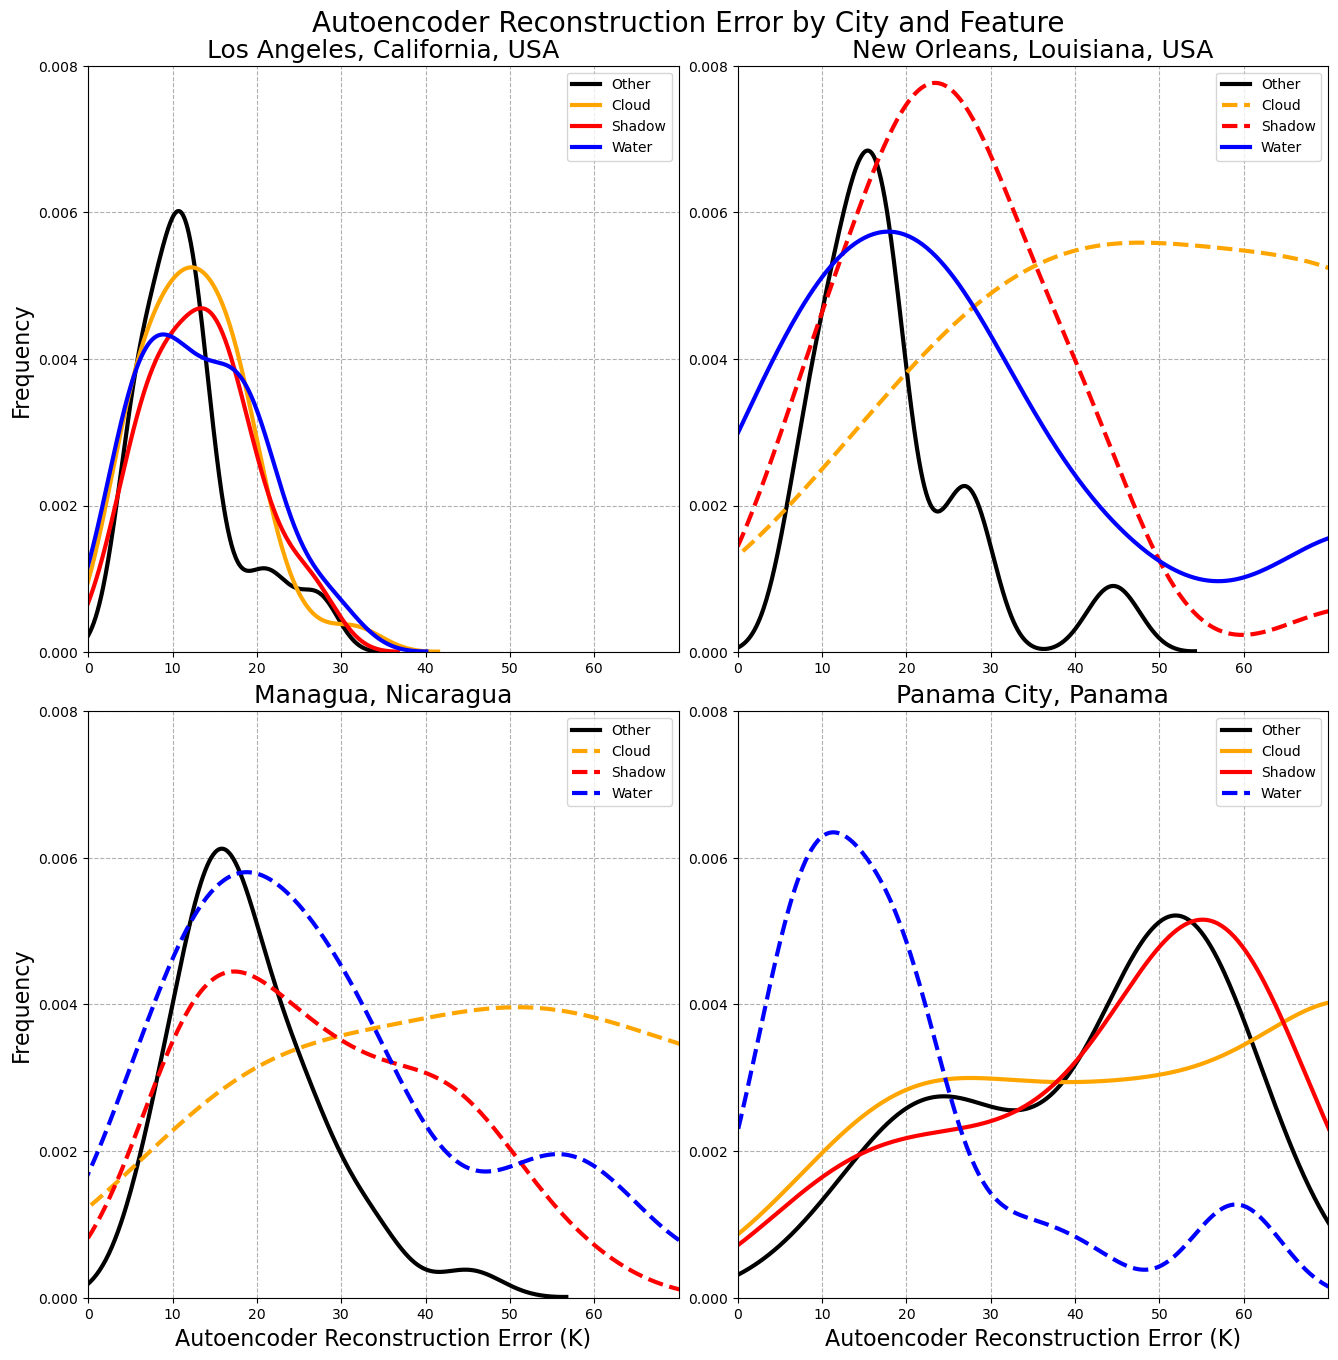

In [42]:
# Same as the prior plot, except four cities are selected
fig, axs = plt.subplots(2, 2)
fig.set_size_inches(16, 16)
plt.subplots_adjust(hspace=0.1, wspace=0.1)
x = np.arange(0, 60)

interesting_cities = ['Los_Angeles', 'New_Orleans', 'Managua', 'Panama_City']

for i in range(2):
    for j in range(2):
        city = interesting_cities[i*2+j]
        index = np.where(np.array(cities) == city)[0][0]

        overall_losses = overall_losses_all_city[index]
        cloud_losses = cloud_losses_all_city[index]
        shadow_losses = shadow_losses_all_city[index]
        water_losses = water_losses_all_city[index]

        nan_mask = np.isnan(overall_losses)
        overall_pdf = KDEUnivariate(overall_losses[~nan_mask])
        overall_pdf.fit()
        overall_dist = overall_pdf.density/np.sum(overall_pdf.density)

        nan_mask = np.isnan(cloud_losses)
        cloud_pdf = KDEUnivariate(cloud_losses[~nan_mask])
        cloud_pdf.fit()
        cloud_dist = cloud_pdf.density/np.sum(cloud_pdf.density)

        nan_mask = np.isnan(shadow_losses)
        shadow_pdf = KDEUnivariate(shadow_losses[~nan_mask])
        shadow_pdf.fit()
        shadow_dist = shadow_pdf.density/np.sum(shadow_pdf.density)

        nan_mask = np.isnan(water_losses)
        water_pdf = KDEUnivariate(water_losses[~nan_mask])
        water_pdf.fit()
        water_dist = water_pdf.density/np.sum(water_pdf.density)

        # Run Mann-Whitney tests for difference of distribution for each feature
        cloud_p_value = stats.mannwhitneyu(overall_losses, cloud_losses, nan_policy='omit').pvalue
        shadow_p_value = stats.mannwhitneyu(overall_losses, shadow_losses, nan_policy='omit').pvalue
        water_p_value = stats.mannwhitneyu(overall_losses, water_losses, nan_policy='omit').pvalue

        # Plot PDFs of each feature
        axs[i, j].plot(overall_pdf.support, overall_dist, color='k', linewidth=3, label='Other')
        if cloud_p_value < 0.05:
            axs[i, j].plot(cloud_pdf.support, cloud_dist, color='orange', linewidth=3, label='Cloud', linestyle='dashed')
        else:
            axs[i, j].plot(cloud_pdf.support, cloud_dist, color='orange', linewidth=3, label='Cloud')
        if shadow_p_value < 0.05:
            axs[i, j].plot(shadow_pdf.support, shadow_dist, color='r', linewidth=3, label='Shadow', linestyle='dashed')
        else:
            axs[i, j].plot(shadow_pdf.support, shadow_dist, color='r', linewidth=3, label='Shadow')
        if water_p_value < 0.05:
            axs[i, j].plot(water_pdf.support, water_dist, color='b', linewidth=3, label='Water', linestyle='dashed')
        else:
            axs[i, j].plot(water_pdf.support, water_dist, color='b', linewidth=3, label='Water')

        axs[i,j].legend()
        axs[i,j].set_title(city_str_dict[city].replace('\n', ''), fontsize=18)
        axs[i,j].grid(True, linestyle='dashed')

        # Format y-axis ticks to 3 decimal places
        formatter_y = mticker.StrMethodFormatter("{x:.3f}")
        axs[i,j].yaxis.set_major_formatter(formatter_y)
        axs[i,j].set_xlim(left=0, right=70)
        axs[i,j].set_xticks(np.arange(0, 61, 10))
        axs[i,j].set_ylim(bottom=0, top=0.008)
        axs[i,j].set_yticks(np.arange(0, 0.009, 0.002))

        if j == 0:
            axs[i,j].set_ylabel('Frequency', fontsize=16)
        if i == 1:
            axs[i,j].set_xlabel('Autoencoder Reconstruction Error (K)', fontsize=16)

        plt.suptitle('Autoencoder Reconstruction Error by City and Feature', y=0.915, fontsize=20)

fig.savefig('/glade/work/jstarfeldt/autoencoder/Poster_feature_reconstruction_error.svg', transparent=True, bbox_inches='tight')